# Principal Components Analysis Nutrition Exercise
En este ejercicio no vas a montar ningún modelo de Machine Learning supervisado, sino aprenderás a trabajar con PCA: pretratar el dato antes de calcular sus PCs, interpretarlos, graficar y escoger número de componentes según varianza.

Importa las librerías necesarias

In [11]:
# Tratamiento de datos
# ==============================================================================
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm

# Gráficos
# ==============================================================================
import matplotlib.pyplot as plt
import matplotlib.font_manager
from matplotlib import style
style.use('ggplot') or plt.style.use('ggplot')

# Preprocesado y modelado
# ==============================================================================
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import scale

# Configuración warnings
# ==============================================================================
import warnings
warnings.filterwarnings('ignore')

### Importa los datos
1. Importa los datos: *nndb.csv*
2. Observa las columnas que hay, así como su tipo.

In [5]:
df = pd.read_csv('data/nndb_flat.csv', sep=',', index_col=0)
df.head()

,FoodGroup,ShortDescrip,Descrip,CommonName,MfgName,ScientificName,Energy_kcal,Protein_g,Fat_g,Carb_g,...,Folate_USRDA,Niacin_USRDA,Riboflavin_USRDA,Thiamin_USRDA,Calcium_USRDA,Copper_USRDA,Magnesium_USRDA,Phosphorus_USRDA,Selenium_USRDA,Zinc_USRDA
ID,,,,,,,,,,,,,,,,,,,,,
1001,Dairy and Egg Products,"BUTTER,WITH SALT","Butter, salted",NaN,NaN,NaN,717.0,0.85,81.11,0.06,...,0.0075,0.002625,0.026154,0.004167,0.020000,0.000000,0.004762,0.034286,0.018182,0.008182
1002,Dairy and Egg Products,"BUTTER,WHIPPED,WITH SALT","Butter, whipped, with salt",NaN,NaN,NaN,717.0,0.85,81.11,0.06,...,0.0075,0.002625,0.026154,0.004167,0.020000,0.000018,0.004762,0.032857,0.018182,0.004545
1003,Dairy and Egg Products,"BUTTER OIL,ANHYDROUS","Butter oil, anhydrous",NaN,NaN,NaN,876.0,0.28,99.48,0.00,...,0.0000,0.000188,0.003846,0.000833,0.003333,0.000001,0.000000,0.004286,0.000000,0.000909
1004,Dairy and Egg Products,"CHEESE,BLUE","Cheese, blue",NaN,NaN,NaN,353.0,21.40,28.74,2.34,...,0.0900,0.063500,0.293846,0.024167,0.440000,0.000044,0.054762,0.552857,0.263636,0.241818
1005,Dairy and Egg Products,"CHEESE,BRICK","Cheese, brick",NaN,NaN,NaN,371.0,23.24,29.68,2.79,...,0.0500,0.007375,0.270000,0.011667,0.561667,0.000027,0.057143,0.644286,0.263636,0.236364


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8618 entries, 1001 to 93600
Data columns (total 44 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   FoodGroup         8618 non-null   object 
 1   ShortDescrip      8618 non-null   object 
 2   Descrip           8618 non-null   object 
 3   CommonName        1063 non-null   object 
 4   MfgName           1560 non-null   object 
 5   ScientificName    732 non-null    object 
 6   Energy_kcal       8618 non-null   float64
 7   Protein_g         8618 non-null   float64
 8   Fat_g             8618 non-null   float64
 9   Carb_g            8618 non-null   float64
 10  Sugar_g           8618 non-null   float64
 11  Fiber_g           8618 non-null   float64
 12  VitA_mcg          8618 non-null   float64
 13  VitB6_mg          8618 non-null   float64
 14  VitB12_mcg        8618 non-null   float64
 15  VitC_mg           8618 non-null   float64
 16  VitE_mg           8618 non-null   float64
 

In [7]:
df.describe()

,Energy_kcal,Protein_g,Fat_g,Carb_g,Sugar_g,Fiber_g,VitA_mcg,VitB6_mg,VitB12_mcg,VitC_mg,...,Folate_USRDA,Niacin_USRDA,Riboflavin_USRDA,Thiamin_USRDA,Calcium_USRDA,Copper_USRDA,Magnesium_USRDA,Phosphorus_USRDA,Selenium_USRDA,Zinc_USRDA
count,8618.000000,8618.00000,8618.000000,8618.000000,8618.000000,8618.000000,8618.000000,8618.000000,8618.000000,8618.000000,...,8618.000000,8618.000000,8618.000000,8618.000000,8618.000000,8618.000000,8618.000000,8618.000000,8618.000000,8618.000000
mean,226.438617,11.52391,10.647024,21.819062,6.560253,2.023242,93.968786,0.264369,1.225260,7.925377,...,0.125765,0.213222,0.182499,0.174881,0.061176,0.000191,0.077965,0.222838,0.229363,0.179111
std,169.388910,10.55059,15.866353,27.239000,13.602098,4.313670,779.362205,0.478614,4.319183,57.582758,...,0.466402,0.302161,0.346062,0.431974,0.167803,0.000615,0.133496,0.290133,0.514406,0.305292
min,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,93.000000,2.47000,0.992500,0.040000,0.000000,0.000000,0.000000,0.034250,0.000000,0.000000,...,0.000000,0.023875,0.035385,0.025000,0.007500,0.000033,0.023810,0.052857,0.001818,0.020909
50%,191.000000,8.28500,5.235000,8.945000,0.370000,0.300000,1.500000,0.120000,0.080000,0.000000,...,0.017500,0.131250,0.115385,0.064583,0.015833,0.000088,0.047619,0.190000,0.070909,0.076818
75%,336.000000,19.97750,13.900000,32.900000,5.300000,2.400000,21.000000,0.355000,1.297500,2.500000,...,0.062500,0.314328,0.200000,0.185833,0.051667,0.000161,0.069048,0.308571,0.387273,0.245455
max,902.000000,88.32000,100.000000,100.000000,99.800000,79.000000,30000.000000,12.000000,98.890000,2400.000000,...,14.702500,7.968750,13.461538,19.479167,6.136667,0.016722,1.859524,14.168571,34.854545,8.268182


### Mira a ver la correlación entre las variables numéricas
¿Qué pasa con las columnas USRDA? ¿Hay que tomar alguna decisión?

In [10]:
correlacion = df.corr(numeric_only = True)
correlacion

,Energy_kcal,Protein_g,Fat_g,Carb_g,Sugar_g,Fiber_g,VitA_mcg,VitB6_mg,VitB12_mcg,VitC_mg,...,Folate_USRDA,Niacin_USRDA,Riboflavin_USRDA,Thiamin_USRDA,Calcium_USRDA,Copper_USRDA,Magnesium_USRDA,Phosphorus_USRDA,Selenium_USRDA,Zinc_USRDA
Energy_kcal,1.000000,0.110302,0.806795,0.487096,0.313151,0.197338,0.026329,0.121872,-0.012292,-0.033495,...,0.145936,0.174991,0.155830,0.187439,0.123571,0.099513,0.255880,0.195181,0.056673,0.112766
Protein_g,0.110302,1.000000,0.054715,-0.301974,-0.266170,-0.072777,0.026483,0.228485,0.245423,-0.066456,...,0.008939,0.376939,0.202480,0.098360,0.046888,0.158900,0.218611,0.444608,0.378369,0.416315
Fat_g,0.806795,0.054715,1.000000,-0.054116,-0.001962,-0.028842,0.024379,-0.046950,-0.020786,-0.059993,...,-0.058049,-0.022671,-0.036286,-0.005785,0.015039,0.042765,0.070781,0.066086,0.037559,0.028264
Carb_g,0.487096,-0.301974,-0.054116,1.000000,0.615344,0.458192,0.001871,0.195571,-0.094636,0.076745,...,0.325170,0.173285,0.232408,0.281809,0.189106,0.062106,0.287207,0.073180,-0.114600,-0.012187
Sugar_g,0.313151,-0.266170,-0.001962,0.615344,1.000000,0.115916,0.010143,0.088767,-0.050450,0.064152,...,0.161257,0.034378,0.125225,0.097751,0.129540,-0.005837,0.041308,-0.049784,-0.123708,-0.021991
Fiber_g,0.197338,-0.072777,-0.028842,0.458192,0.115916,1.000000,0.005910,0.242804,-0.052045,0.081852,...,0.249075,0.135257,0.157703,0.205211,0.232286,0.185044,0.542038,0.158422,-0.035897,0.085154
VitA_mcg,0.026329,0.026483,0.024379,0.001871,0.010143,0.005910,1.000000,0.136605,0.581004,0.111279,...,0.108517,0.151679,0.325709,0.052921,0.034822,0.569945,0.024572,0.055814,0.048043,0.070541
VitB6_mg,0.121872,0.228485,-0.046950,0.195571,0.088767,0.242804,0.136605,1.000000,0.264325,0.271305,...,0.550087,0.714143,0.581678,0.417011,0.177268,0.116326,0.293169,0.213395,0.109004,0.447143
VitB12_mcg,-0.012292,0.245423,-0.020786,-0.094636,-0.050450,-0.052045,0.581004,0.264325,1.000000,0.007264,...,0.158483,0.279033,0.436182,0.099601,0.011715,0.570642,0.004124,0.148774,0.215308,0.298136
VitC_mg,-0.033495,-0.066456,-0.059993,0.076745,0.064152,0.081852,0.111279,0.271305,0.007264,1.000000,...,0.072797,0.209107,0.225928,0.056987,0.111825,0.025460,0.115222,0.012000,-0.035218,0.018476


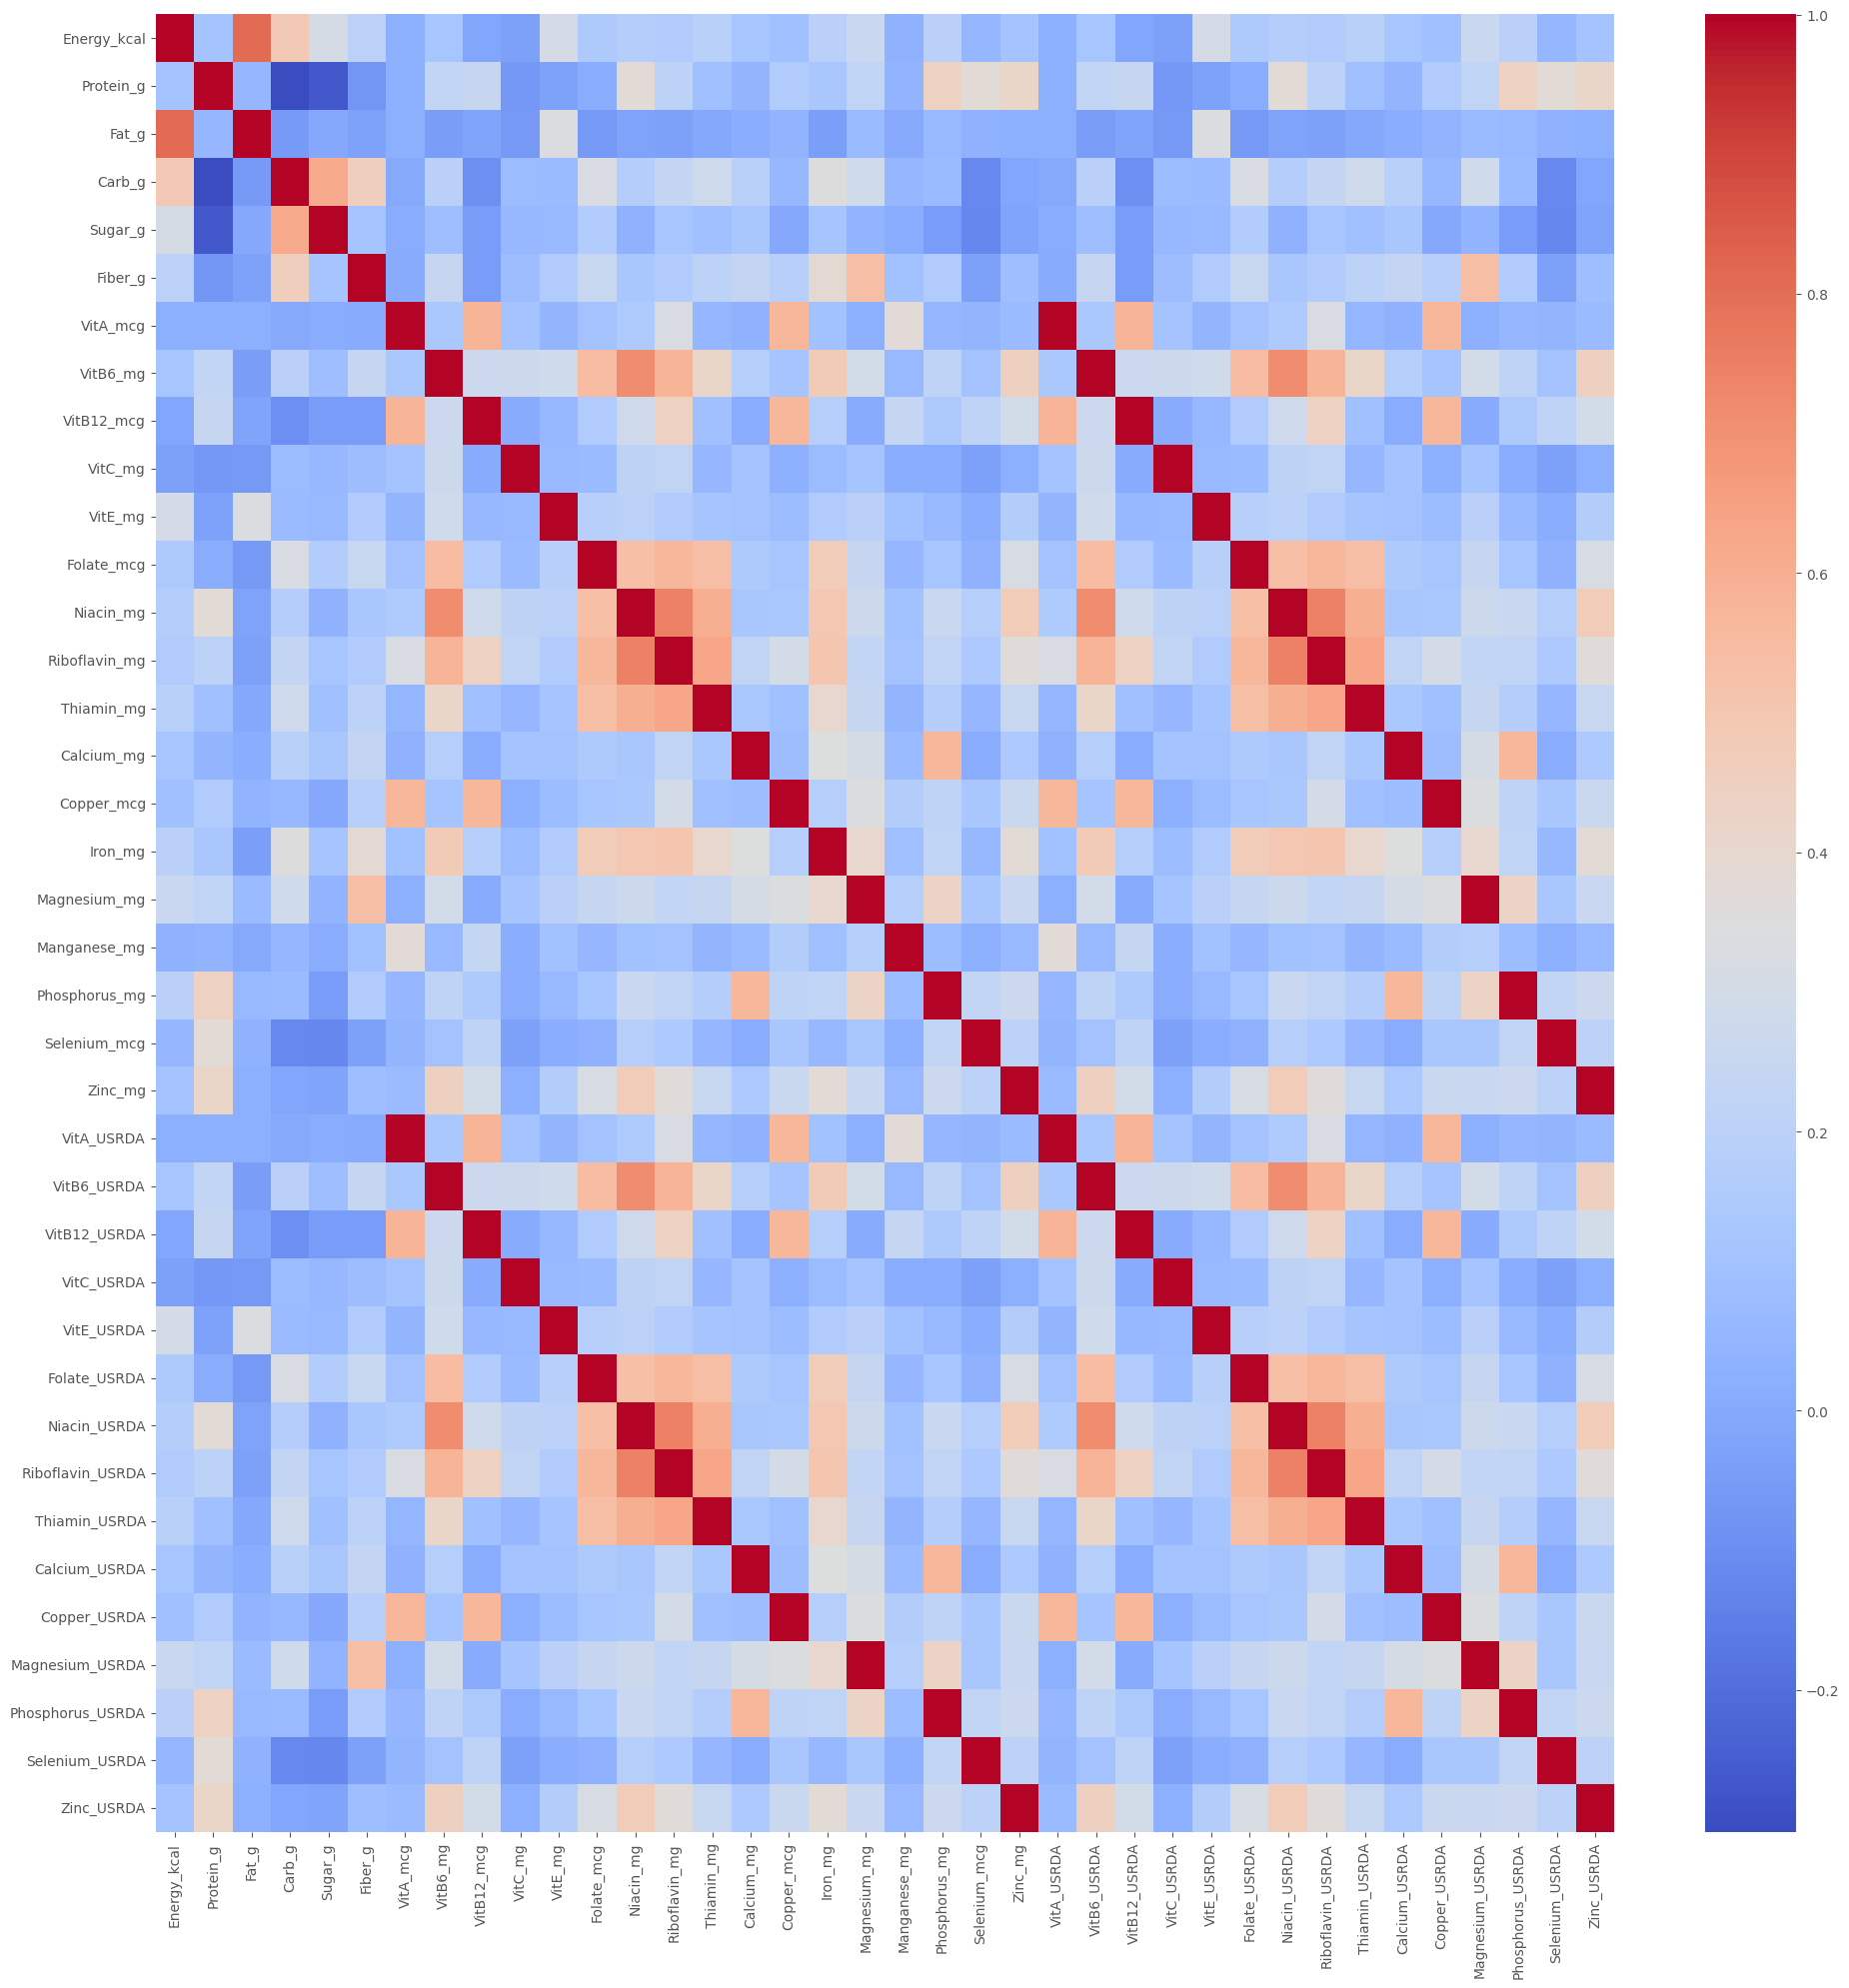

In [13]:
plt.figure(figsize=(20, 20))  # Ajusta según necesidad
sns.heatmap(correlacion, annot=False, cmap='coolwarm', cbar=True)
plt.tight_layout()
plt.show()

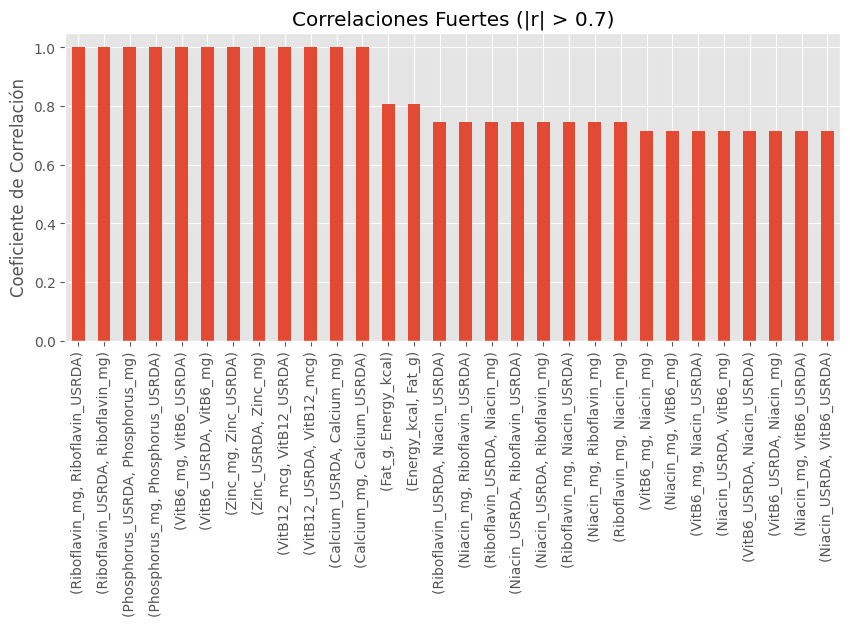

In [14]:
# Convertir matriz de correlación a pares (filtra valores absolutos > 0.7)
corr_pairs = correlacion.unstack().sort_values(key=abs, ascending=False)
strong_pairs = corr_pairs[(abs(corr_pairs) > 0.7) & (corr_pairs < 1)]

# Gráfico de barras
strong_pairs.plot(kind='bar', figsize=(10, 4))
plt.title("Correlaciones Fuertes (|r| > 0.7)")
plt.ylabel("Coeficiente de Correlación")
plt.show()

# las USRDA tienen su homólogo sin USRDA

### Variables no numéricas
Elimina las variables de texto del dataset

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8618 entries, 1001 to 93600
Data columns (total 44 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   FoodGroup         8618 non-null   object 
 1   ShortDescrip      8618 non-null   object 
 2   Descrip           8618 non-null   object 
 3   CommonName        1063 non-null   object 
 4   MfgName           1560 non-null   object 
 5   ScientificName    732 non-null    object 
 6   Energy_kcal       8618 non-null   float64
 7   Protein_g         8618 non-null   float64
 8   Fat_g             8618 non-null   float64
 9   Carb_g            8618 non-null   float64
 10  Sugar_g           8618 non-null   float64
 11  Fiber_g           8618 non-null   float64
 12  VitA_mcg          8618 non-null   float64
 13  VitB6_mg          8618 non-null   float64
 14  VitB12_mcg        8618 non-null   float64
 15  VitC_mg           8618 non-null   float64
 16  VitE_mg           8618 non-null   float64
 

In [22]:
df_1 = df.drop(columns = ['FoodGroup', 'ShortDescrip','Descrip', 'CommonName', 'MfgName','ScientificName'])
df_1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8618 entries, 1001 to 93600
Data columns (total 38 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Energy_kcal       8618 non-null   float64
 1   Protein_g         8618 non-null   float64
 2   Fat_g             8618 non-null   float64
 3   Carb_g            8618 non-null   float64
 4   Sugar_g           8618 non-null   float64
 5   Fiber_g           8618 non-null   float64
 6   VitA_mcg          8618 non-null   float64
 7   VitB6_mg          8618 non-null   float64
 8   VitB12_mcg        8618 non-null   float64
 9   VitC_mg           8618 non-null   float64
 10  VitE_mg           8618 non-null   float64
 11  Folate_mcg        8618 non-null   float64
 12  Niacin_mg         8618 non-null   float64
 13  Riboflavin_mg     8618 non-null   float64
 14  Thiamin_mg        8618 non-null   float64
 15  Calcium_mg        8618 non-null   float64
 16  Copper_mcg        8618 non-null   float64
 

### Distribuciones
Muchas de las variables tienen asimetría hacia la derecha. Deberíamos transformarlas para conseguir distribuciones normales y mejorar las correlaciones de cara al PCA y a futuros modelos lineales que vayamos a probar. Transforma todas las variables realizando una transformación Logarítmica.

In [27]:
# Calcular skewness para cada columna numérica
skewness = df_1.select_dtypes(include=['number']).skew()
skewness

Energy_kcal          1.168243
Protein_g            1.170610
Fat_g                3.306166
Carb_g               1.157211
Sugar_g              2.953324
Fiber_g              5.793241
VitA_mcg            24.090421
VitB6_mg             7.557554
VitB12_mcg          13.034297
VitC_mg             30.907462
VitE_mg             13.849434
Folate_mcg          10.327038
Niacin_mg            6.435334
Riboflavin_mg       11.312592
Thiamin_mg          17.510062
Calcium_mg          13.427978
Copper_mcg          15.943149
Iron_mg              6.839288
Magnesium_mg         5.565037
Manganese_mg        39.741772
Phosphorus_mg       18.553944
Selenium_mcg        38.207299
Zinc_mg              9.629128
VitA_USRDA          24.090421
VitB6_USRDA          7.557554
VitB12_USRDA        13.034297
VitC_USRDA          30.907462
VitE_USRDA          13.849434
Folate_USRDA        10.327038
Niacin_USRDA         6.435334
Riboflavin_USRDA    11.312592
Thiamin_USRDA       17.510062
Calcium_USRDA       13.427978
Copper_USR

In [28]:
# Aplicar log1p a columnas numéricas
df_log = df_1.apply(np.log1p)

# Verificar nueva asimetría
skewness_log = df_log.skew()
print("\nAsimetría después de log1p:\n", skewness_log)


Asimetría después de log1p:
 Energy_kcal         -1.212031
Protein_g           -0.396545
Fat_g                0.125756
Carb_g              -0.077008
Sugar_g              1.003597
Fiber_g              1.095043
VitA_mcg             1.027066
VitB6_mg             2.606092
VitB12_mcg           1.811908
VitC_mg              1.587730
VitE_mg              3.195811
Folate_mcg           0.549609
Niacin_mg            0.284155
Riboflavin_mg        3.261326
Thiamin_mg           3.397270
Calcium_mg           0.029462
Copper_mcg           5.178007
Iron_mg              1.356769
Magnesium_mg        -0.622496
Manganese_mg         4.887523
Phosphorus_mg       -1.342631
Selenium_mcg         0.143818
Zinc_mg              0.811837
VitA_USRDA           8.251278
VitB6_USRDA          3.245980
VitB12_USRDA         2.657388
VitC_USRDA           7.494619
VitE_USRDA           6.682666
Folate_USRDA         4.874118
Niacin_USRDA         2.075452
Riboflavin_USRDA     3.583802
Thiamin_USRDA        3.680899
Calcium_US

(array([19., 15.,  3.,  0.,  1.]),
 array([-1.34263051,  2.09753706,  5.53770463,  8.9778722 , 12.41803977,
        15.85820734]),
 <BarContainer object of 5 artists>)

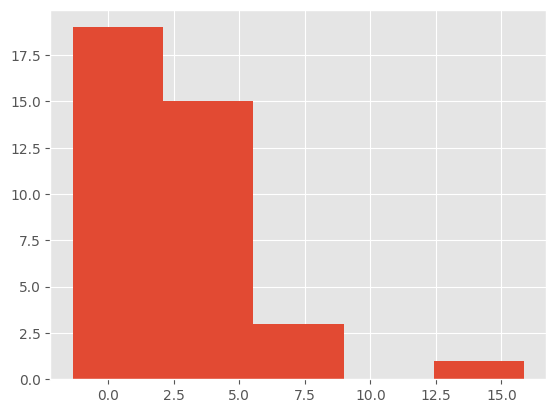

In [32]:
plt.hist(skewness_log, bins=5)


In [35]:
df_log.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8618 entries, 1001 to 93600
Data columns (total 38 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Energy_kcal       8618 non-null   float64
 1   Protein_g         8618 non-null   float64
 2   Fat_g             8618 non-null   float64
 3   Carb_g            8618 non-null   float64
 4   Sugar_g           8618 non-null   float64
 5   Fiber_g           8618 non-null   float64
 6   VitA_mcg          8618 non-null   float64
 7   VitB6_mg          8618 non-null   float64
 8   VitB12_mcg        8618 non-null   float64
 9   VitC_mg           8618 non-null   float64
 10  VitE_mg           8618 non-null   float64
 11  Folate_mcg        8618 non-null   float64
 12  Niacin_mg         8618 non-null   float64
 13  Riboflavin_mg     8618 non-null   float64
 14  Thiamin_mg        8618 non-null   float64
 15  Calcium_mg        8618 non-null   float64
 16  Copper_mcg        8618 non-null   float64
 

In [43]:
df_log.var(axis=0)

Energy_kcal         9.499897e-01
Protein_g           1.117007e+00
Fat_g               1.394793e+00
Carb_g              2.593734e+00
Sugar_g             1.634297e+00
Fiber_g             6.714881e-01
VitA_mcg            4.179343e+00
VitB6_mg            5.762167e-02
VitB12_mcg          4.284905e-01
VitC_mg             1.603241e+00
VitE_mg             3.053587e-01
Folate_mcg          3.295344e+00
Niacin_mg           7.069184e-01
Riboflavin_mg       4.690944e-02
Thiamin_mg          4.933421e-02
Calcium_mg          2.271326e+00
Copper_mcg          4.112451e-02
Iron_mg             5.074223e-01
Magnesium_mg        1.670113e+00
Manganese_mg        1.466764e-01
Phosphorus_mg       2.953328e+00
Selenium_mcg        2.057279e+00
Zinc_mg             4.837239e-01
VitA_USRDA          3.969652e-02
VitB6_USRDA         2.814369e-02
VitB12_USRDA        1.824785e-01
VitC_USRDA          2.809857e-02
VitE_USRDA          1.809873e-02
Folate_USRDA        4.422641e-02
Niacin_USRDA        3.510735e-02
Riboflavin

In [44]:
df_log.describe()

,Energy_kcal,Protein_g,Fat_g,Carb_g,Sugar_g,Fiber_g,VitA_mcg,VitB6_mg,VitB12_mcg,VitC_mg,...,Folate_USRDA,Niacin_USRDA,Riboflavin_USRDA,Thiamin_USRDA,Calcium_USRDA,Copper_USRDA,Magnesium_USRDA,Phosphorus_USRDA,Selenium_USRDA,Zinc_USRDA
count,8618.000000,8618.000000,8618.000000,8618.000000,8618.000000,8618.000000,8618.000000,8618.000000,8618.000000,8618.000000,...,8618.000000,8618.000000,8618.000000,8618.000000,8618.000000,8618.000000,8618.000000,8618.000000,8618.000000,8618.000000
mean,5.075155,2.073285,1.783379,2.118534,1.018775,0.670117,1.698699,0.197749,0.454007,0.804010,...,0.085485,0.172883,0.146044,0.134753,0.052379,0.000191,0.069477,0.185767,0.176996,0.145462
std,0.974674,1.056886,1.181014,1.610507,1.278396,0.819444,2.044344,0.240045,0.654592,1.266192,...,0.210301,0.187370,0.182828,0.197283,0.105693,0.000611,0.098473,0.162586,0.218131,0.179027
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.543295,1.244155,0.689388,0.039221,0.000000,0.000000,0.000000,0.033676,0.000000,0.000000,...,0.000000,0.023594,0.034773,0.024693,0.007472,0.000033,0.023530,0.051508,0.001817,0.020693
50%,5.257495,2.228400,1.830178,2.297070,0.314811,0.262364,0.895880,0.113329,0.076961,0.000000,...,0.017349,0.123323,0.109199,0.062583,0.015709,0.000088,0.046520,0.173953,0.068508,0.074010
75%,5.820083,3.043450,2.701361,3.523415,1.840550,1.223775,3.091042,0.303801,0.831820,1.252763,...,0.060625,0.273326,0.182322,0.170446,0.050376,0.000161,0.066768,0.268936,0.327340,0.219501
max,6.805723,4.492225,4.615121,4.615121,4.613138,4.382027,10.308986,2.564949,4.604070,7.783641,...,2.753820,2.193746,2.671493,3.019408,1.965246,0.016584,1.050655,2.719226,3.579470,2.226587


### Estandarizado
Estandariza cada variable.

No es necesario que dividas en train y test.

In [41]:
#scaler = StandardScaler()
#df_scaled = scaler.fit_transform(df_log)

### Implementación del PCA
Prueba a montar un PCA con todos los componentes. Para ello utiliza los datos previamente transformados y escalados.

In [45]:
pca_pipe = make_pipeline(StandardScaler(), PCA(n_components=38))
pca_pipe.fit(df_log)

modelo_pca = pca_pipe['pca']

In [46]:
pca_pipe['pca']

PCA(n_components=38)

In [47]:
modelo_pca.components_


array([[ 1.36429289e-01,  1.94350916e-01,  9.47046058e-02, ...,
         2.04595296e-01,  1.59688363e-01,  2.09609382e-01],
       [-1.16233791e-02, -2.28310401e-01, -1.26302225e-01, ...,
        -5.95781029e-02, -2.24403492e-01, -1.26430954e-01],
       [ 2.10944432e-01,  1.55488323e-01,  1.81050133e-01, ...,
         2.23385132e-01,  6.16001463e-02, -1.15106502e-02],
       ...,
       [-7.68614973e-03,  5.04844236e-03,  9.19080013e-03, ...,
        -7.88324647e-03, -1.27654578e-02,  2.37651139e-02],
       [-1.71788966e-03, -2.31097853e-04,  3.28560821e-03, ...,
         2.81785338e-03,  1.91138854e-03, -2.82403007e-03],
       [-4.65083617e-04,  3.78087052e-04, -4.74350526e-04, ...,
        -1.64182944e-04, -3.64623668e-03,  2.12059293e-03]],
      shape=(38, 38))

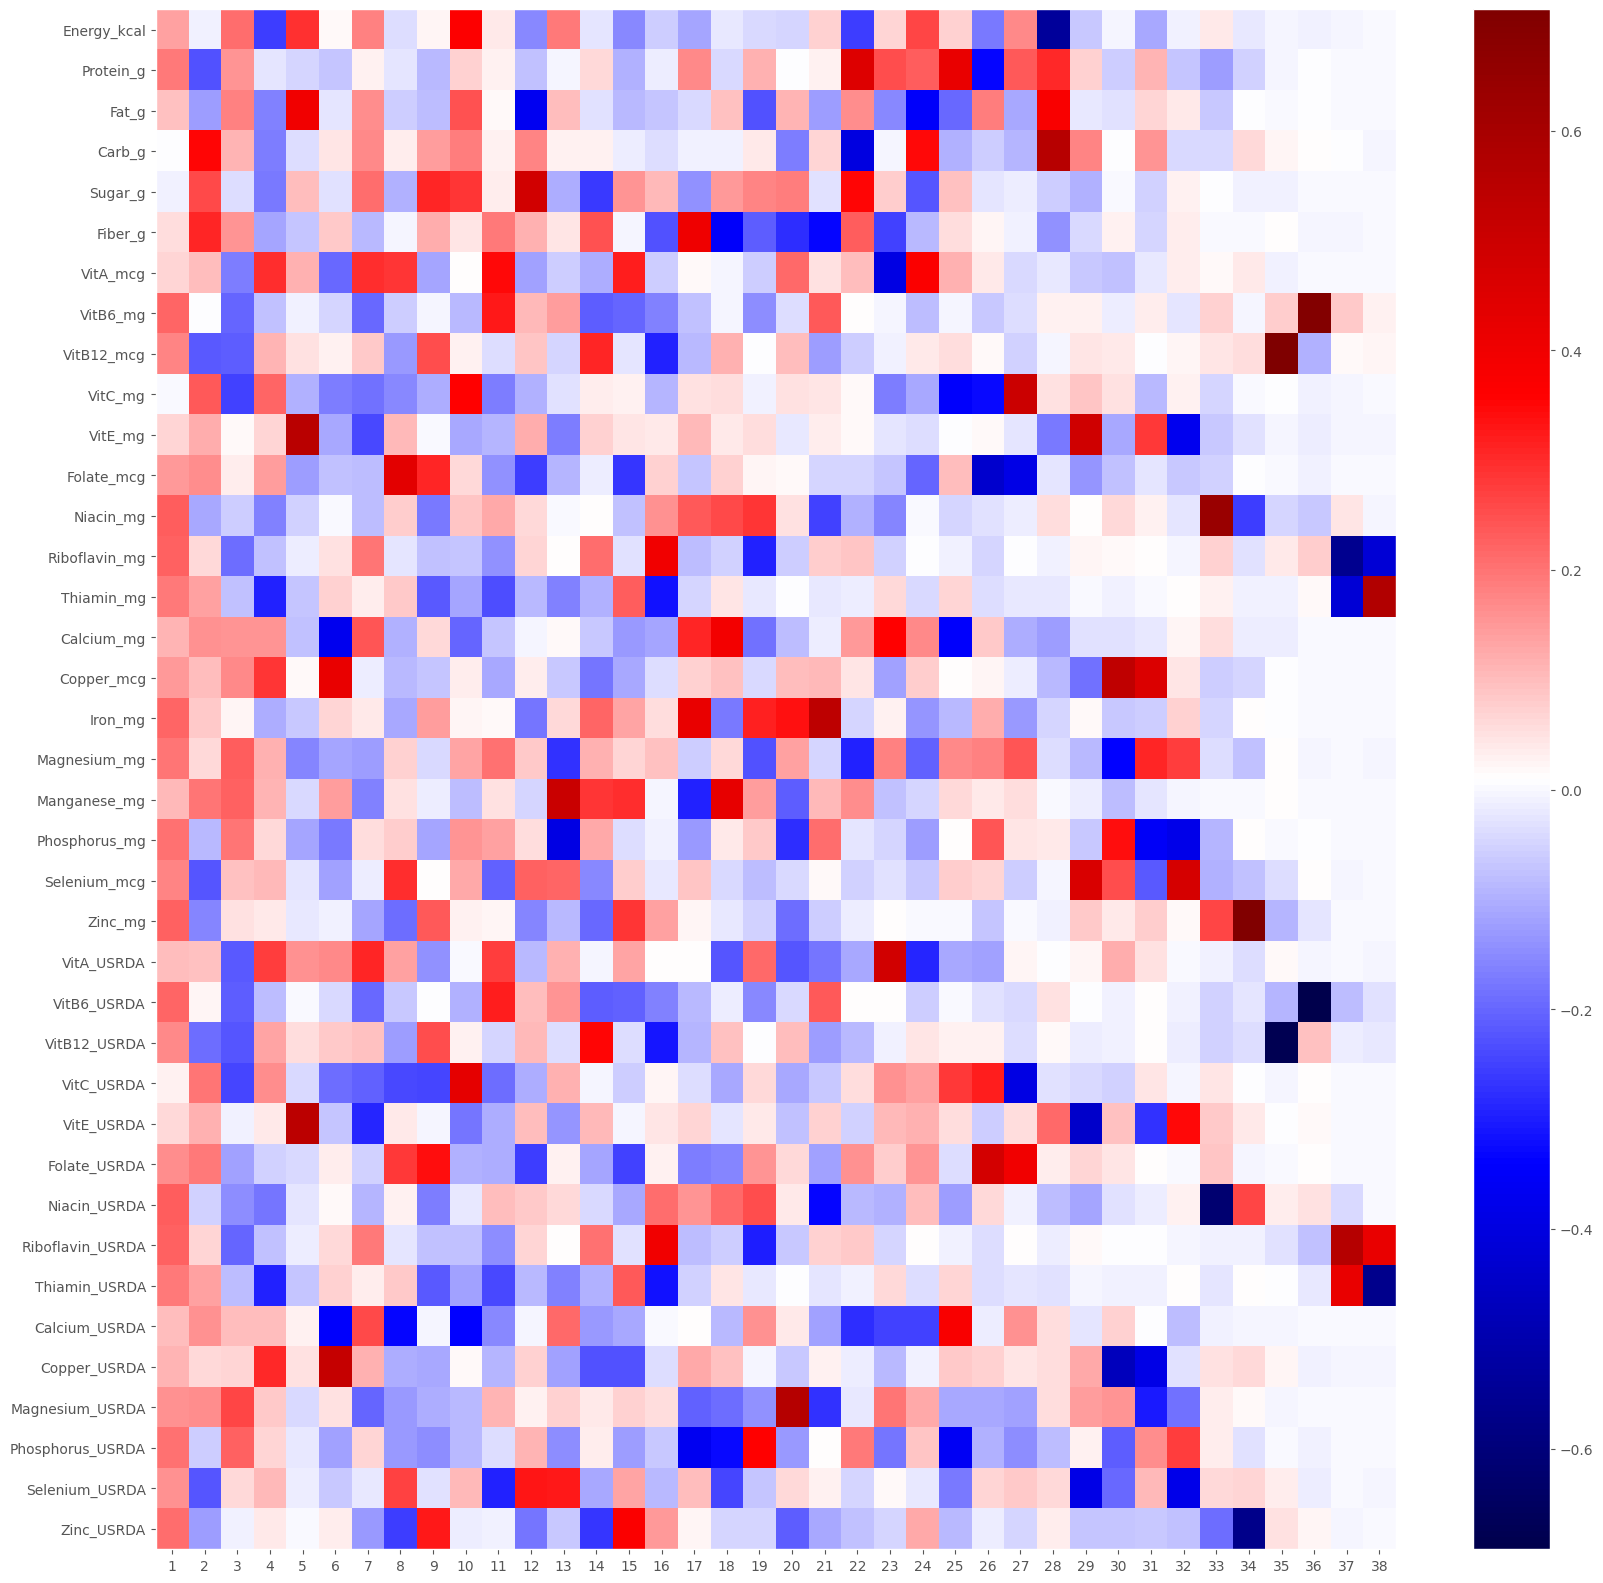

In [49]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(20, 20))
componentes = modelo_pca.components_
plt.imshow(componentes.T, cmap='seismic', aspect='auto')
plt.yticks(range(len(df_log.columns)), df_log.columns)
plt.xticks(range(len(df_log.columns)), np.arange(modelo_pca.n_components_) + 1)
plt.grid(False)
plt.colorbar();

### Aportación de cada PCA
Visualiza en un diagrama de líneas la suma acumulada de la varianza explicativa del PCA.

Si tuviéses que quedarte con 70-75 % de la varianza original, ¿con cuántos Principal Components te quedarías?

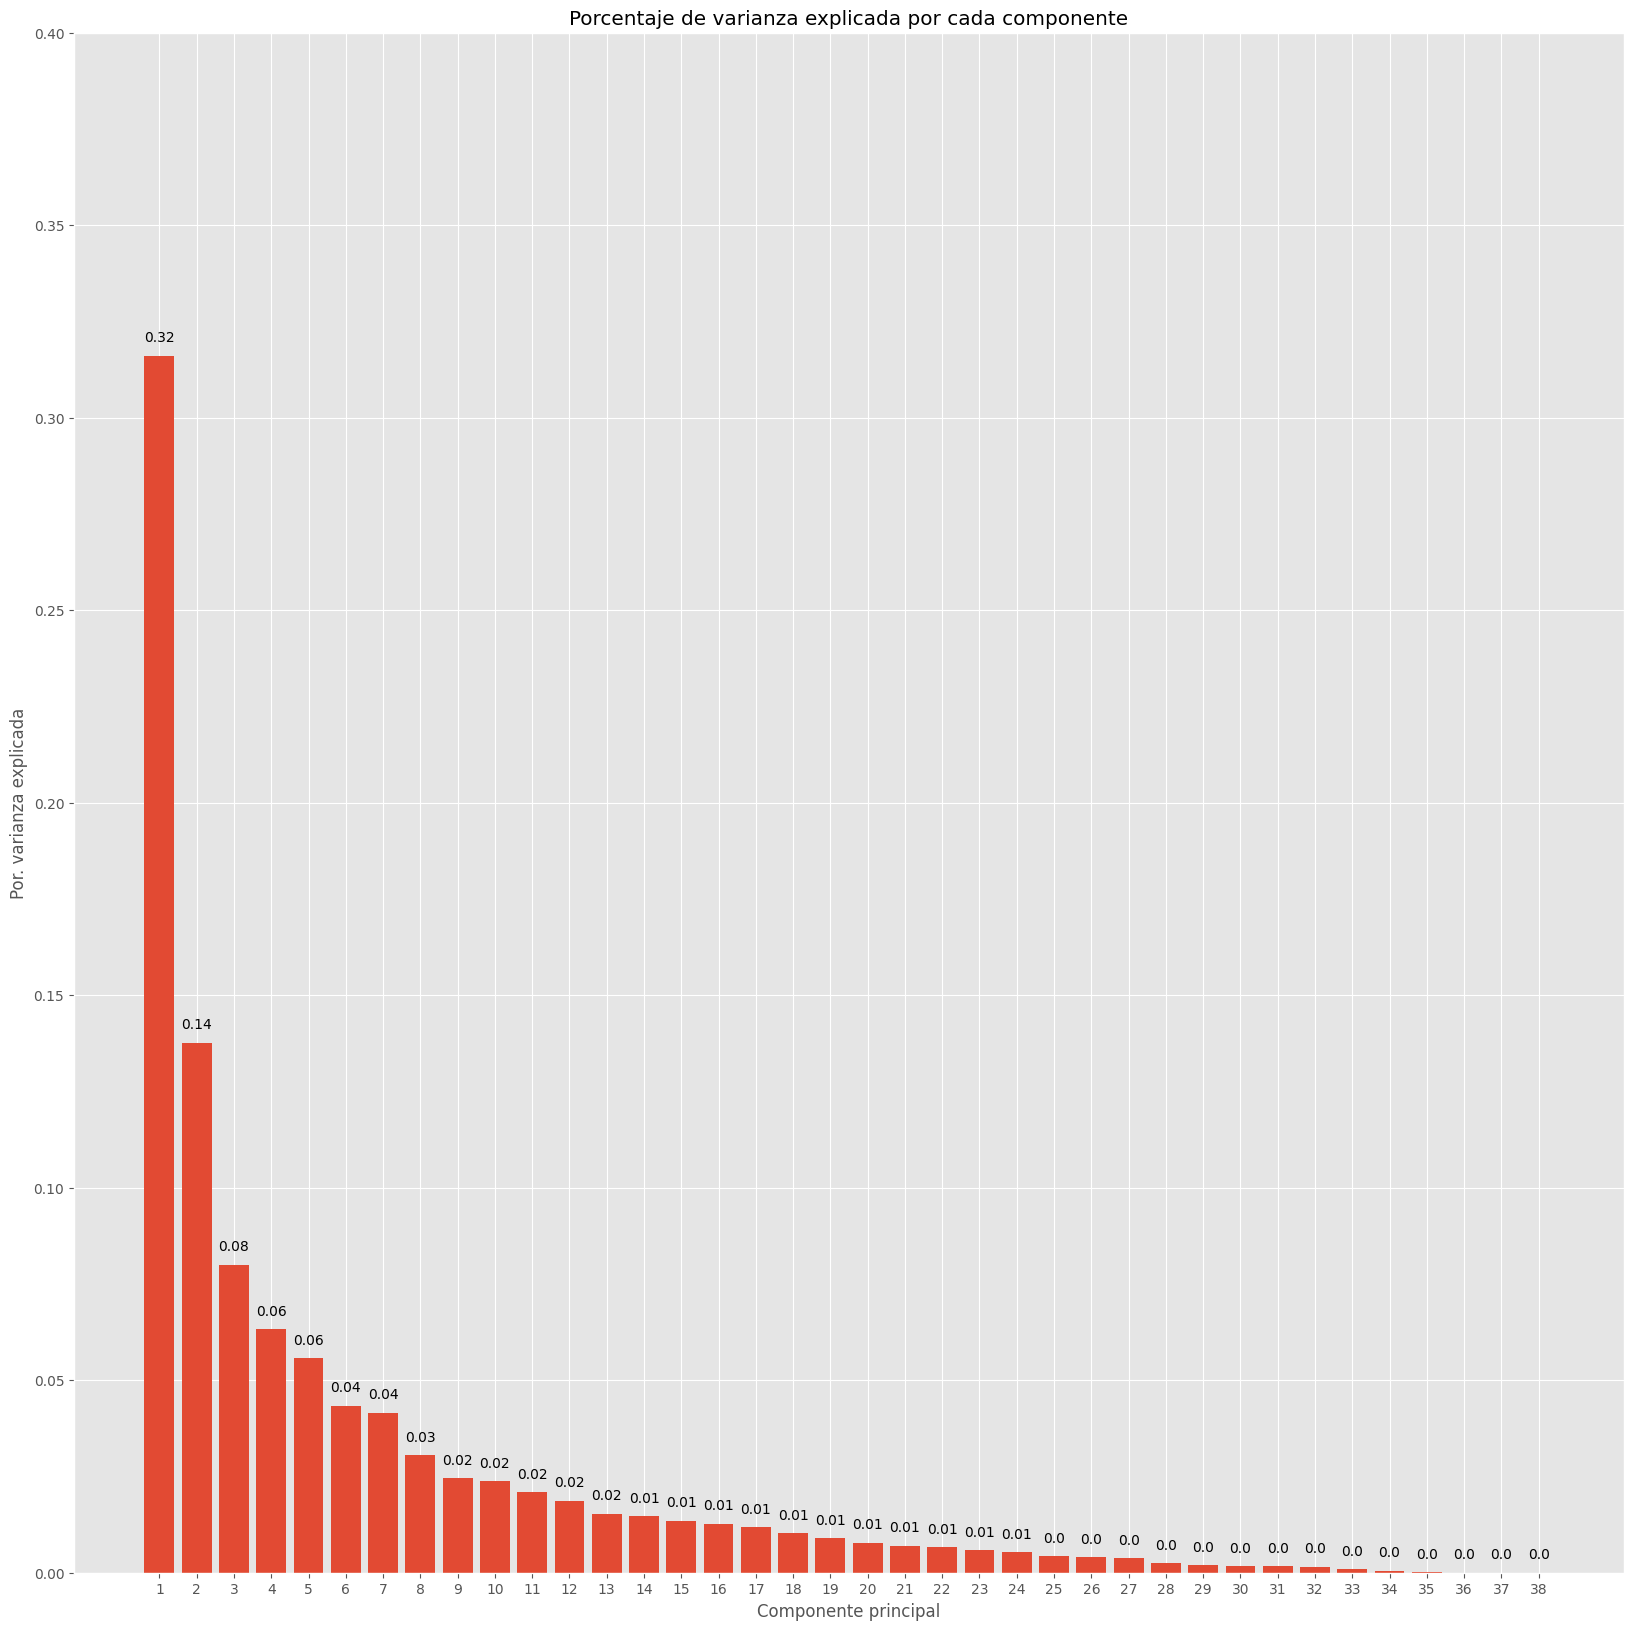

In [52]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(20, 20))
ax.bar(
    x      = np.arange(modelo_pca.n_components_) + 1,
    height = modelo_pca.explained_variance_ratio_
)

for x, y in zip(np.arange(len(df_log.columns)) + 1, modelo_pca.explained_variance_ratio_):
    label = round(y, 2)
    ax.annotate(
        label,
        (x,y),
        textcoords="offset points",
        xytext=(0,10),
        ha='center'
    )

ax.set_xticks(np.arange(modelo_pca.n_components_) + 1)
ax.set_ylim(0, 0.4)
ax.set_title('Porcentaje de varianza explicada por cada componente')
ax.set_xlabel('Componente principal')
ax.set_ylabel('Por. varianza explicada');

## Feat. Red
Crea un nuevo PCA con X Principal Components, siendo X la cantidad de PC escogidos en el apartado anterior.

Obtén el nuevo dataset con el mismo número de registros que el original, pero en este caso con X features, que representan los PC elegidos.

### ¿Qué grupo de comida tiene los valores más altos en cada categoría?
Determina para cada Principal Component, los 3 grupos de comida (*FoodGroup*) con los valores del PC más altos.